In [36]:
%matplotlib inline
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import random
import pandas as pd
import itertools
import math
from matplotlib.colors import LogNorm
import time
#from numpy.random import *
import numexpr as ne
from IPython.display import clear_output
import os
import sys
import warnings
warnings.filterwarnings('ignore')
#from google.colab import drive
#drive.mount('/content/drive')

In [37]:
data1=pd.read_csv( 'RoughTEOS_02.dat', skiprows=18, encoding='shift_jis' , skipinitialspace=True )
data1

,Axis (deg),I (cts),I0 (cts),Atten.
0,68.5884,5,3389.0840,1.0
1,68.5984,3,3385.8774,1.0
2,68.6084,6,3381.0929,1.0
3,68.6184,1,3376.6467,1.0
4,68.6284,3,3381.9034,1.0
...,...,...,...,...
196,70.5484,2,3112.0680,1.0
197,70.5584,5,3113.6517,1.0
198,70.5684,1,3119.3050,1.0
199,70.5784,0,3114.3961,1.0


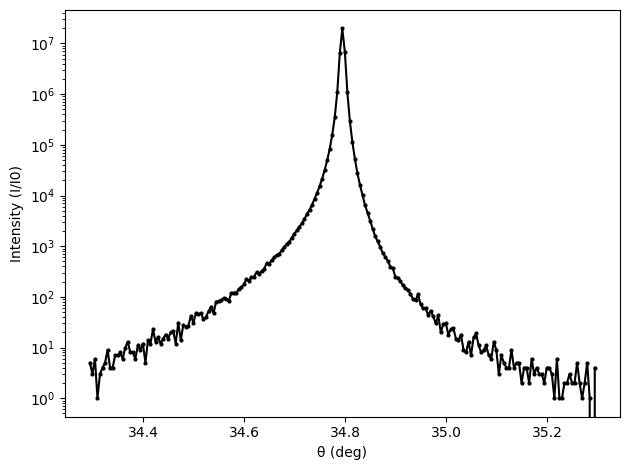

In [38]:
#データをplot
lam = 1.55  # Å
two_theta = data1.iloc[:,0].to_numpy()   # 2θ       
y  = data1.iloc[:,1].to_numpy()  
I0 = data1.iloc[:,2].to_numpy()  # I0
atten = 5000

I_corr = y / (np.maximum(I0, 1e-12) * np.maximum(atten, 1e-12))

theta = two_theta / 2.0
q_data = (2*np.pi/lam) * np.sin(np.deg2rad(theta))  # q [1/Å] = (2π/λ) sinθ

plt.plot(theta, y, 'ko-', ms=2)  #k，黑色 o显示圆点，实线链接用o-，ms=粗细度  theta---q可以转换
plt.yscale('log')
plt.xlabel('θ (deg)'); plt.ylabel('Intensity (I/I0)')
plt.tight_layout()
plt.show()

In [39]:
y

array([       5,        3,        6,        1,        3,        4,
              5,        9,        4,        4,        7,        7,
              8,        6,       10,       13,        8,        8,
              6,       11,        9,       12,        5,       14,
             12,       23,       13,       16,       12,       15,
             18,       15,       20,       21,       12,       31,
             14,       28,       26,       27,       42,       31,
             47,       46,       47,       36,       40,       52,
             64,       48,       81,       82,       86,       94,
             92,       82,      119,      121,      120,      143,
            154,      176,      224,      209,      242,      249,
            305,      286,      318,      356,      458,      443,
            529,      599,      674,      702,      840,      959,
           1120,     1224,     1483,     1768,     2042,     2422,
           2824,     3401,     4373,     5211,     6537,     8

In [40]:
#CTR MODEL 04-

def CTRmodel04( q_data, I0, a, mu, aS, NS ):
    #
    # exp_sum= 0j + 0
    #exp_sum = np.zeros_like( q_data, dtype=np.complex128 )
    exp_sum = 0j+0    
    #
    for n_ in range(NS+1):
        exp_sum += np.exp( - n_* mu ) * np.exp( 1j * q_data * aS * n_ )
    #
    exp_sum += 1 / ( np.sqrt(2) * np.sin( q_data * a / 2 ) )
    #
    Iq_ = 10**I0 * abs( exp_sum )**2
    #
    return Iq_

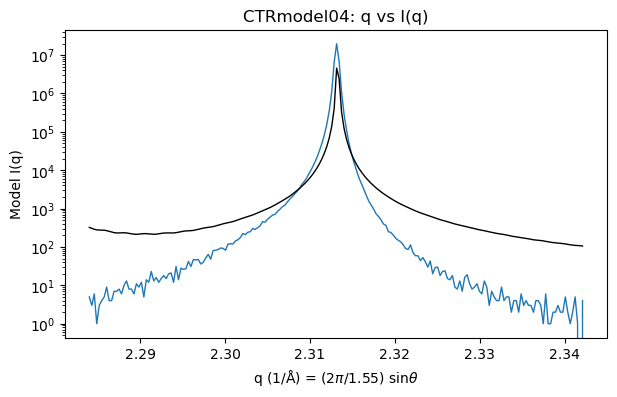

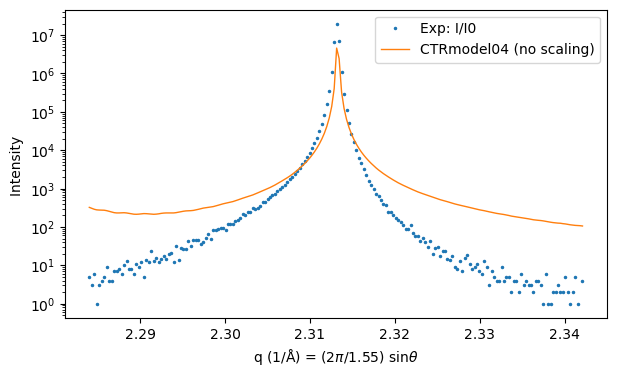

In [41]:
# --- パラメータ---
a  = 5.4323   # Å (Si 晶格常数)
aS = 5.528  # Å (表面层间距，示例同 a)
mu = 8.00E-3    # 衰减係数
NS = 500     # 层数；層数
I0 = 0.007  # 振幅标定
bg = 5    

I_model = CTRmodel04(q_data, I0, a, mu, aS, NS)+bg
I_model_int = np.asarray(I_model, dtype = int)
#I_model = (lambda v: v/np.maximum(np.nanmax(v), 1e-12))(CTRmodel04(q_data, I0, a, mu, aS, NS))

#a2  = 5.4323   # Å (Si 晶格常数)
#aS2 = 5.5  # Å (表面层间距，示例同 a)
#mu2 = 8.00E-3    # 衰减係数
#NS2 = 120000     # 层数；層数
#I02 = -7.229     # 振幅标定

#I_model2 = CTRmodel04(q_data, I02, a2, mu2, aS2, NS2)
#I_model2 = (lambda v: v/np.maximum(np.nanmax(v), 1e-12))(CTRmodel04(q_data, I02, a2, mu2, aS2, NS2))

# --- plot ---
plt.figure(figsize=(7,4))
plt.plot(q_data, y, '-', lw=1)
plt.plot(q_data, I_model_int, 'k-', lw=1)
plt.yscale('log') 
plt.xlabel(r'q (1/Å) = (2$\pi$/1.55) sin$\theta$')
plt.ylabel('Model I(q)')
plt.title('CTRmodel04: q vs I(q)')
plt.show()

#----比较----
plt.figure(figsize=(7,4))
plt.plot(q_data, y, '.', ms=3, label='Exp: I/I0')
plt.plot(q_data, I_model_int, '-', lw=1, label='CTRmodel04 (no scaling)')
plt.yscale('log')  
plt.xlabel(r'q (1/Å) = (2$\pi$/1.55) sin$\theta$')
plt.ylabel('Intensity ')
plt.legend()
plt.show()

In [42]:
def CTRmodel04fit(q_data ,num_temp,_p_):
    _I0_ = _p_[:,0].reshape(num_temp,1)
    _a_ = _p_[:,1].reshape(num_temp,1)
    _mu_ = _p_[:,2].reshape(num_temp,1)
    _aS_ = _p_[:,3].reshape(num_temp,1)
    _bg_ = _p_[:,4].reshape(num_temp,1)

    y =  CTRmodel04(q_data, _I0_, _a_, _mu_, _aS_, NS)+_bg_
    # y = (lambda v: v/np.maximum(np.nanmax(v), 1e-12))(CTRmodel04(q, I0, a, mu, aS, NS))
    return y

In [43]:
# 擬似フォークト2つによるピークフィット
# メトロポリス法によるパラメータ更新
#ポアソンノイズ
def update_param_p(i,E,n,sigma_R,q_data,y,const,_p_,ratio_p,rslt_p,_rslt_p0_,_rslt_p1_,_rslt_p2_,_rslt_p3_,_rslt_p4_,stepsize_p0,stepsize_p1,stepsize_p2,stepsize_p3,stepsize_p4,
                   _ratio_p_,num_temp,num_para,_p_min_,_p_max_,burn_in_length):
    #num_para = np.size(_p_max_)
    # temp=0はprior（事前分布）に基づいてサンプリング
    _p_[0,0] = (_p_max_[0]-_p_min_[0])*np.random.rand()+_p_min_[0]
    _p_[0,1] = (_p_max_[1]-_p_min_[1])*np.random.rand()+_p_min_[1]
    _p_[0,2] = (_p_max_[2]-_p_min_[2])*np.random.rand()+_p_min_[2]
    _p_[0,3] = (_p_max_[3]-_p_min_[3])*np.random.rand()+_p_min_[3]
    _p_[0,4] = (_p_max_[4]-_p_min_[4])*np.random.rand()+_p_min_[4]

    for _ii_ in range(num_para):
        _select_ = np.random.randint(0,num_para,num_temp) #パラメータ間の相関がサンプリングに影響しないようにランダムにパラメータ選択して更新。
        #_select_ = np.int(_ii_)*np.ones(num_temp,dtype="int8") # 順番にパラメータ更新する場合
        _next_p_ = 1*_p_
        for _j_ in range(1,num_temp):# temp=0は別のサンプリングを行う
            _ratio_p_[num_para*_j_+_select_[_j_]] = np.append(_ratio_p_[num_para*_j_+_select_[_j_]],0)
            if(_select_[_j_]==0):
                _next_p_[_j_,0] += stepsize_p0[_j_]*(2*np.random.rand()-1)
            if(_select_[_j_]==1):
                _next_p_[_j_,1] += stepsize_p1[_j_]*(2*np.random.rand()-1)
            if(_select_[_j_]==2):
                _next_p_[_j_,2] += stepsize_p2[_j_]*(2*np.random.rand()-1)
            if(_select_[_j_]==3):
                _next_p_[_j_,3] += stepsize_p3[_j_]*(2*np.random.rand()-1)
            if(_select_[_j_]==4):
                _next_p_[_j_,4] += stepsize_p4[_j_]*(2*np.random.rand()-1)
        _y_ = CTRmodel04fit(q_data ,num_temp,_next_p_)
        # ガウスノイズ
        #next_E = 1/2/n/sigma_R**2*np.linalg.norm(y-(
        #         _y_                                                                                                                
        #         ),axis=1)**2
        
        # ポアソンノイズ
        next_E = 1/n/sigma_R**2*(np.sum(_y_-np.log(_y_)*y,axis=1)+const)
        
        prob = np.exp(-n*temp*(next_E-E)) - np.random.rand(num_temp)
        J = np.where(prob>0)
        for _jj_ in J[0]:
            if(_p_min_[_select_[_jj_]]<= _next_p_[_jj_,_select_[_jj_]]<=_p_max_[_select_[_jj_]]):
                _p_[_jj_,_select_[_jj_]] = _next_p_[_jj_,_select_[_jj_]]
                E[_jj_] = next_E[_jj_]
                if(_jj_>0):
                    (_ratio_p_[num_para*_jj_+_select_[_jj_]])[-1] +=1#採択率についての履歴を残す
                if(i>burn_in_length):
                    ratio_p[_jj_,_select_[_jj_]] += 1#採択率そのもの
        rslt_p[_select_[num_temp-1]] = np.append(rslt_p[_select_[num_temp-1]],_p_[num_temp-1,_select_[num_temp-1]])#最低温の履歴
        for _kk_ in range(1,num_temp):#全レプリカのサンプリング履歴を残す
            if(_select_[_kk_]==0):
                _rslt_p0_[_kk_] = np.append(_rslt_p0_[_kk_],_p_[_kk_,0])
            if(_select_[_kk_]==1):
                _rslt_p1_[_kk_] = np.append(_rslt_p1_[_kk_],_p_[_kk_,1])
            if(_select_[_kk_]==2):
                _rslt_p2_[_kk_] = np.append(_rslt_p2_[_kk_],_p_[_kk_,2])
            if(_select_[_kk_]==3):
                _rslt_p3_[_kk_] = np.append(_rslt_p3_[_kk_],_p_[_kk_,3])
            if(_select_[_kk_]==4):
                _rslt_p4_[_kk_] = np.append(_rslt_p4_[_kk_],_p_[_kk_,4])
    #temp=0は必ず更新
    E[0] = next_E[0]
    ratio_p[0,:] = 0
    _rslt_p0_[0] = np.append(_rslt_p0_[0],_p_[0,0])
    _rslt_p1_[0] = np.append(_rslt_p1_[0],_p_[0,1])
    _rslt_p2_[0] = np.append(_rslt_p2_[0],_p_[0,2])
    _rslt_p3_[0] = np.append(_rslt_p3_[0],_p_[0,3])
    _rslt_p4_[0] = np.append(_rslt_p4_[0],_p_[0,4])
    return E

In [44]:
# 擬似フォークト関数
# ローレンツ関数とガウス関数の幅を別々に設定
def psV(x,mu,w_l,w_g,A,x0):
    y = A*(mu*2/np.pi*w_l/(4*(x-x0)**2+w_l**2)+(1-mu)*np.sqrt(4*np.log(2))/np.sqrt(np.pi)/w_g*np.exp(-4*np.log(2)/w_g**2*(x-x0)**2))
    return y
# ローレンツ関数とガウス関数の幅を共通
#def psV(x,mu,w,A,x0):
#    y = A*(mu*2/np.pi*w/(4*(x-x0)**2+w**2)+(1-mu)*np.sqrt(4*np.log(2))/np.sqrt(np.pi)/w*np.exp(-4*np.log(2)/w**2*(x-x0)**2))
#    return y

In [45]:
#x

In [ ]:
y  

array([       5,        3,        6,        1,        3,        4,
              5,        9,        4,        4,        7,        7,
              8,        6,       10,       13,        8,        8,
              6,       11,        9,       12,        5,       14,
             12,       23,       13,       16,       12,       15,
             18,       15,       20,       21,       12,       31,
             14,       28,       26,       27,       42,       31,
             47,       46,       47,       36,       40,       52,
             64,       48,       81,       82,       86,       94,
             92,       82,      119,      121,      120,      143,
            154,      176,      224,      209,      242,      249,
            305,      286,      318,      356,      458,      443,
            529,      599,      674,      702,      840,      959,
           1120,     1224,     1483,     1768,     2042,     2422,
           2824,     3401,     4373,     5211,     6537,     8

In [47]:
y

array([       5,        3,        6,        1,        3,        4,
              5,        9,        4,        4,        7,        7,
              8,        6,       10,       13,        8,        8,
              6,       11,        9,       12,        5,       14,
             12,       23,       13,       16,       12,       15,
             18,       15,       20,       21,       12,       31,
             14,       28,       26,       27,       42,       31,
             47,       46,       47,       36,       40,       52,
             64,       48,       81,       82,       86,       94,
             92,       82,      119,      121,      120,      143,
            154,      176,      224,      209,      242,      249,
            305,      286,      318,      356,      458,      443,
            529,      599,      674,      702,      840,      959,
           1120,     1224,     1483,     1768,     2042,     2422,
           2824,     3401,     4373,     5211,     6537,     8

In [52]:
# メインのプログラム
#_sigma_R_ = 0.02/2 # ノイズ推定用の計算範囲を決めるため、予想されるノイズ標準偏差よりも小さい値を入れる。ノイズ推定をしない場合は真値を入れる。
_sigma_R_ = 1 #ポアソンの場合
_dir_ = "dzx_kaiseki_data_05"# 解析結果の保存先フォルダ名を入力
os.mkdir(_dir_) # 保存先フォルダを作成。（フォルダが既に存在する場合はエラーとなる。）

# 初期値を事前分布から生成するか？
ini_pri = 1 # 1:生成する 0:生成しない（ハイパーパラメータ調整時以外は事前分布から生成する。）

np.random.seed(seed=1)# 解析結果に再現性を持たせるため乱数のseedを設定。

num_para = 5 # パラメータ数を入力　

# stepsizeの調整　＃パラメータを整数値としてりようできるか
_st_p0_ = 0.01
_st_p1_ = 0.01
_st_p2_ = 0.001
_st_p3_ = 0.001
_st_p4_ = 0.5


scale_d = 1
_d_p0_ = 0.45*scale_d
_d_p1_ = 0.4*scale_d
_d_p2_ = 0.45*scale_d
_d_p3_ = 0.45*scale_d
_d_p4_ = 0.5*scale_d


_alpha_p0_ = 10**(3.1)
_alpha_p1_ = 10**(1.2)
_alpha_p2_ = 10**(1.3)
_alpha_p3_ = 10**(1.5)
_alpha_p4_ = 10**(3.2)


# 解析条件を設定
cycle = 10#20000#50000 #繰り返し回数
num_temp = 50 #逆温度の個数、偶数で設定
proportion = 1.4 #逆温度を生成する際の等比係数
burn_in_length = 5#5000#20000 #焼きなましの繰り返し回数

n = np.size(y)
ratio_p0 = np.zeros(num_temp)
ratio_p1 = np.zeros(num_temp)
ratio_p2 = np.zeros(num_temp)
ratio_p3 = np.zeros(num_temp)
ratio_p4 = np.zeros(num_temp)

ratio_temp = np.zeros(num_temp)
mean_E = np.zeros(num_temp)

# 初期値を設定（ハイパーパラメータ調整を行うときはプレフィットの値を入れる）
initial_p0 = 1
initial_p1 = 5.43
initial_p2 = 0.002
initial_p3 = 5.528
initial_p4 = 1


initial_p = np.ones(num_para)#パラメータ数の空箱を作る
initial_p[0] = initial_p0
initial_p[1] = initial_p1
initial_p[2] = initial_p2
initial_p[3] = initial_p3
initial_p[4] = initial_p4


# 各パラメータの範囲を事前分布として設定。
min_p0 = 0.001
max_p0 = 10
min_p1 = 5.4
max_p1 = 5.5
min_p2 = 0.002
max_p2 = 0.01
min_p3 = 5.31
max_p3 = 5.71
min_p4 = 0
max_p4 = 2.4#5


_p_max_ = np.array([max_p0,max_p1,max_p2,max_p3,max_p4])
_p_min_ = np.array([min_p0,min_p1,min_p2,min_p3,min_p4])
ratio_p = np.zeros((num_temp,np.size(_p_max_)))
rslt_p = [initial_p0,initial_p1,initial_p2,initial_p3,initial_p4]

# tempの生成 b=temp/sigma**2 : ノイズ推定を行う場合
_sigma_ = _sigma_R_#予測されるσよりも小さな値を入れる
sigma_R = 1 # ここを1とすることでtempにまとめる
temp = np.array([proportion**(j-num_temp+1)/_sigma_**2 for j in range(num_temp)])

# tempの生成 β=temp：ノイズ推定を行わない場合
#temp = np.array([proportion**(j-num_temp+1) for j in range(num_temp)])
#sigma_R = _sigma_R_ # sigma_Rにノイズ分散の真値を入れる

# stepsizeの生成 分岐点の情報をαとして入れる
stepsize_p0 = np.where(temp<=1/_alpha_p0_,_st_p0_,_st_p0_/(_alpha_p0_*temp)**_d_p0_)
stepsize_p1 = np.where(temp<=1/_alpha_p1_,_st_p1_,_st_p1_/(_alpha_p1_*temp)**_d_p1_)
stepsize_p2 = np.where(temp<=1/_alpha_p2_,_st_p2_,_st_p2_/(_alpha_p2_*temp)**_d_p2_)
stepsize_p3 = np.where(temp<=1/_alpha_p3_,_st_p3_,_st_p3_/(_alpha_p3_*temp)**_d_p3_)
stepsize_p4 = np.where(temp<=1/_alpha_p4_,_st_p4_,_st_p4_/(_alpha_p4_*temp)**_d_p4_)



temp[0] = 0
stepsize_p0[0] = _st_p0_
stepsize_p1[0] = _st_p1_
stepsize_p2[0] = _st_p2_
stepsize_p3[0] = _st_p3_
stepsize_p4[0] = _st_p4_

# プレフィット結果を初期値とする場合（ハイパーパラメータ調整を行う時のみ）
p0 = initial_p0*np.ones(num_temp)
p1 = initial_p1*np.ones(num_temp)
p2 = initial_p2*np.ones(num_temp)
p3 = initial_p3*np.ones(num_temp)
p4 = initial_p4*np.ones(num_temp)

_p_ = np.ones(num_temp).reshape(num_temp,1)*initial_p

# 初期値を事前分布から乱数生成する場合
if(ini_pri==1):
    _p_ = np.zeros((num_temp,np.size(_p_max_)))
    _p_[:,0] = (_p_max_[0]-_p_min_[0])*np.random.rand(num_temp)+_p_min_[0]
    _p_[:,1] = (_p_max_[1]-_p_min_[1])*np.random.rand(num_temp)+_p_min_[1]
    _p_[:,2] = (_p_max_[2]-_p_min_[2])*np.random.rand(num_temp)+_p_min_[2]
    _p_[:,3] = (_p_max_[3]-_p_min_[3])*np.random.rand(num_temp)+_p_min_[3]
    _p_[:,4] = (_p_max_[4]-_p_min_[4])*np.random.rand(num_temp)+_p_min_[4]
    
_y_ = CTRmodel04fit(q_data ,num_temp,_p_)
# ガウスノイズ
#E = 1/2/n/sigma_R**2*np.linalg.norm(y-(
#         _y_                                                                                                                
#         ),axis=1)**2

# ポアソンノイズ
const = 0
for i_y in range(np.size(y)):
    for j_y in range(y[i_y]):
        const = const + np.log(j_y+1)
E = 1/n/sigma_R**2*(np.sum(_y_-np.log(_y_)*y,axis=1)+const)

E_ini = E[0]
_E_ = 1*E
_mean_E_ = 1*E
_rslt_p_ = 1*_p_
_rslt_p0_ = list(_p_[:,0])
_rslt_p1_ = list(_p_[:,1])
_rslt_p2_ = list(_p_[:,2])
_rslt_p3_ = list(_p_[:,3])
_rslt_p4_ = list(_p_[:,4])

_ratio_p_ = list(np.ones(np.size(_p_max_)*num_temp))
_optimal_ = list((_p_.reshape(np.size(_p_max_)*num_temp,1))[:,0])
_optimal_E_ = 1*E
_p_all_ = 1*(_p_.reshape(1,num_temp*np.size(_p_max_)))[0]

st = time.time()
for i in range(cycle):
    #配列は関数中で更新されるため取り出すのはEのみ
    E = update_param_p(i,E,n,sigma_R,q_data,y,const,_p_,ratio_p,rslt_p,_rslt_p0_,_rslt_p1_,_rslt_p2_,_rslt_p3_,_rslt_p4_,stepsize_p0,stepsize_p1,stepsize_p2,stepsize_p3,stepsize_p4,
                _ratio_p_,num_temp,num_para,_p_min_,_p_max_,burn_in_length)

    _p_all_ = np.append(_p_all_,1*(_p_.reshape(1,num_temp*np.size(_p_max_)))[0])

    if(i>burn_in_length):
        mean_E += E
    _mean_E_ = np.append(_mean_E_,E)

    #Exchange_Process
    eo = np.mod(i,2)
    if(eo==0):
        prob = np.exp(n*(temp[eo+1::2]-temp[eo::2])*(E[eo+1::2]-E[eo::2])) - np.random.rand(int(num_temp/2))
        J = 2*np.array(np.where(prob>0))
    else:
        prob = np.exp(n*(temp[eo+1:num_temp-1:2]-temp[eo:num_temp-1:2])*(E[eo+1:num_temp-1:2]-E[eo:num_temp-1:2])) -  np.random.rand(int(num_temp/2))
        J = 2*np.array(np.where(prob>0))+1
    if(i>burn_in_length):
        ratio_temp[J] += 1
    for j in J[0]:
        s = 1*_p_[j,:] # 参照を切るために1をかける
        _p_[j,:] = _p_[j+1,:]
        _p_[j+1,:] = s                

    s = E[J]
    E[J] = E[J+1]
    E[J+1] = s
    # judge_optimal => ノイズ推定時どのレプリカが正解か確定しないので、Eの履歴を残して後から解析する
    _E_ = np.append(_E_,E)
    for j in range(np.size(_p_max_)*num_temp):
        if(i==0):
            _optimal_[j] = np.append(_optimal_[j],(_optimal_[j]))
        if(i>0):
            _optimal_[j] = np.append(_optimal_[j],(_optimal_[j])[-1]) 
    del_E = _optimal_E_ - E
    J = np.where(del_E>0)
    _optimal_E_[J] = 1*E[J]
    for j in J[0]:
        for k in range(np.size(_p_max_)):
            (_optimal_[j*np.size(_p_max_)+k])[-1] = _p_[j,k]

#(i+1,5000)元
    if(np.mod(i+1,10)==0):
        print(i+1,time.time()-st)
        np.save(_dir_+"/ratio_p.npy",ratio_p)
        np.save(_dir_+"/ratio_temp.npy",ratio_temp)
        np.save(_dir_+"/mean_E.npy",mean_E)
        np.save(_dir_+"/_rslt_p0_.npy",_rslt_p0_)
        np.save(_dir_+"/_rslt_p1_.npy",_rslt_p1_)
        np.save(_dir_+"/_rslt_p2_.npy",_rslt_p2_)
        np.save(_dir_+"/_rslt_p3_.npy",_rslt_p3_)
        np.save(_dir_+"/_rslt_p4_.npy",_rslt_p4_)
        np.save(_dir_+"/_E_.npy",_E_)
        np.save(_dir_+"/_p_all_.npy",_p_all_)
        np.save(_dir_+"/_mean_E_.npy",_mean_E_)
        np.save(_dir_+"/_ratio_p_.npy",_ratio_p_)
        np.save(_dir_+"/_optimal_.npy",_optimal_)

print(time.time()-st)

ValueError: operands could not be broadcast together with shapes (24,) (25,) 

In [ ]:
_dir_

In [ ]:
# 採択率のプロット
ratio_p = np.load(_dir_+"/ratio_p.npy")
print("おおむね0.2から0.8の間に収まっていれば成功。")
plt.figure(figsize=(24,10))
for i in range(num_para):
    plt.subplot(3,5,i+1)
    plt.plot(temp,ratio_p[:,i]/(cycle-burn_in_length),label="p{}".format(i))
    plt.xscale("log")
    plt.ylim(0,1)
    plt.xlabel("$b$")
    plt.ylabel("Acceptance ratio") 
    plt.legend()
    plt.show()

In [ ]:
# 各パラメータの採択履歴をプロット
print("収束するまでの焼きなまし区間(burn_in)が十分か確認する。")
i = 49 # 履歴を確認したいレプリカのインデックス（逆温度の数が50の時は0から49までの番号）を入れる
plt.figure(figsize=(24,10))
for j in range(num_para):
    _pp_ = np.load(_dir_+"/_rslt_p{}_.npy".format(j), allow_pickle=True)
    plt.subplot(3,5,j+1)
    plt.plot(_pp_[i],label="p{}".format(j))
    plt.vlines(burn_in_length,np.min(_pp_[i]),np.max(_pp_[i]),label="burn_in",linestyle="dotted")
    plt.legend()
    plt.show()

In [ ]:
# レプリカ交換率とmean_Eのプロット
ratio_temp = np.load(_dir_+"/ratio_temp.npy")
mean_E = np.load(_dir_+"/mean_E.npy")
print("最高温度のレプリカ(b=0)との交換率(右の値がゼロで無いことを確認)",ratio_temp[0]/((cycle-burn_in_length)/2))
_ratio_temp_ = np.zeros((num_temp,2))
_ratio_temp_[:,0] = 1*temp
_ratio_temp_[:,1] = 1*ratio_temp/((cycle-burn_in_length)/2)
_mean_E_ = np.zeros((num_temp,2))
_mean_E_[:,0] = 1*temp
_mean_E_[:,1] = 1*mean_E/(cycle-burn_in_length)

plt.plot(temp[1:num_temp-1],ratio_temp[1:num_temp-1]/((cycle-burn_in_length)/2))
plt.xscale("log")
plt.xlabel("$b$")
plt.ylabel("Exchange ratio")
plt.ylim(0,1)
plt.show()
plt.plot(temp[1:num_temp],n*mean_E[1:num_temp]/(cycle-burn_in_length))
plt.xlabel("$b$")
plt.xscale("log")
plt.yscale("log")
plt.ylabel("$N$ x $mean$_$E$")
plt.show()

In [ ]:
# ノイズ推定
F = []
for i in range(1,num_temp):
    A = 0
    for j in range(i):
        A += (temp[j+1] - temp[j])*mean_E[j+1]/(cycle-burn_in_length)*n
    F = np.append(F,A) #- n/2*(np.log(temp[i])-np.log(2*np.pi)))
plt.plot(temp[1:num_temp],F)
plt.xscale("log")
plt.vlines(temp[np.argmin(F)+1],np.min(F),np.max(F),linestyle="dotted")
#plt.yscale("log")
#plt.ylim(-200,500)
print("自由エネルギーの最小値",np.min(F))
print("推定されたノイズの標準偏差",1/(temp[np.argmin(F)+1])**0.5)
print("最適な逆温度のインデックス",np.argmin(F)+1)
plt.show()

In [ ]:
F[48]

In [ ]:
# 事後確率分布をプロット
i = np.argmin(F)+1 # ノイズ推定で得られた最適な逆温度のインデックスが入る
i = 49#ポアソン
_pp_MPM_ = np.zeros(num_para)
plt.figure(figsize=(24,10))
for j in range(num_para):
    _pp_ = np.load(_dir_+"/_rslt_p{}_.npy".format(j), allow_pickle=True)
    plt.subplot(3,5,j+1)
    plt.title("p{} : std = {:.4f}".format(j,np.std((_pp_[i])[burn_in_length::])))
    plt.hist((_pp_[i])[burn_in_length::],bins=40)
    _pp_hist_ = np.histogram((_pp_[i])[burn_in_length::],bins=40)
    _pp_MPM_[j] = ((_pp_hist_[1])[np.argmax(_pp_hist_[0])+1]+(_pp_hist_[1])[np.argmax(_pp_hist_[0])])/2
    plt.vlines(_pp_MPM_[j],0,1.1*np.max(_pp_hist_[0]),linestyle="dotted",label="{:.4f}".format(_pp_MPM_[j]))
    plt.ylim(0,1.1*np.max(_pp_hist_[0]))
    plt.legend()
    

In [ ]:
# パラメータごとの事後確率分布の最大値を用いたMPM(maximizer of the posterior marginal)推定によるフィッティング結果
I0    = _pp_MPM_[0]
a   = _pp_MPM_[1]
mu  = _pp_MPM_[2]
aS  = _pp_MPM_[3]
Ns  = _pp_MPM_[4]
bg  = _pp_MPM_[5]

#_y_ = psV(x,mu1,w1,A1,x1) + psV(x,mu2,w2,A2,x2)
_y_ =  CTRmodel04( q_data, I0, a, mu, aS, NS ) + bg
plt.plot(x,y,"o",label="Data")
plt.plot(x,_y_,color="r",label="Fitting")
plt.plot(x,model_int,label="Model")
plt.legend()
#plt.xlim(np.max(x),np.min(x))

In [ ]:
_pp_MPM_

In [ ]:
# MAP推定結果
_opt_j_ = 49
num_para = np.size(_p_max_)
I0   = (_optimal_[num_para*_opt_j_])[cycle]
a    = (_optimal_[num_para*_opt_j_+1])[cycle]
mu   = (_optimal_[num_para*_opt_j_+2])[cycle]
aS   = (_optimal_[num_para*_opt_j_+3])[cycle]
Ns   = (_optimal_[num_para*_opt_j_+4])[cycle]
bg   = (_optimal_[num_para*_opt_j_+5])[cycle]

y_map = CTRmodel04(q_data, I0, a, mu, aS, NS)+bg
plt.plot(x,y,"o",label="Data")
plt.plot(x,y_map,color="r",label="Fitting")
#plt.plot(x,model_int,label="Model")